In [ ]:
###
    # This code plot the latitudinal–vertical distribution of soil water content. 
    # 1. Read soil water content data.
    # 2. Calculate water density (kg/m³) and interpolate onto a uniform vertical grid.
    # 3. Mask grid cells within permafrost regions.
    # 4. Calculate multi-year mean and Plot latitudinal–vertical distribution.
    # 5. Output: Figure S7.
###

In [1]:
import xarray as xr
import numpy as np
import glob
import matplotlib.pyplot as plt
import warnings
from scipy.interpolate import griddata
import matplotlib.colors as mcolors
import os
warnings.filterwarnings('ignore')

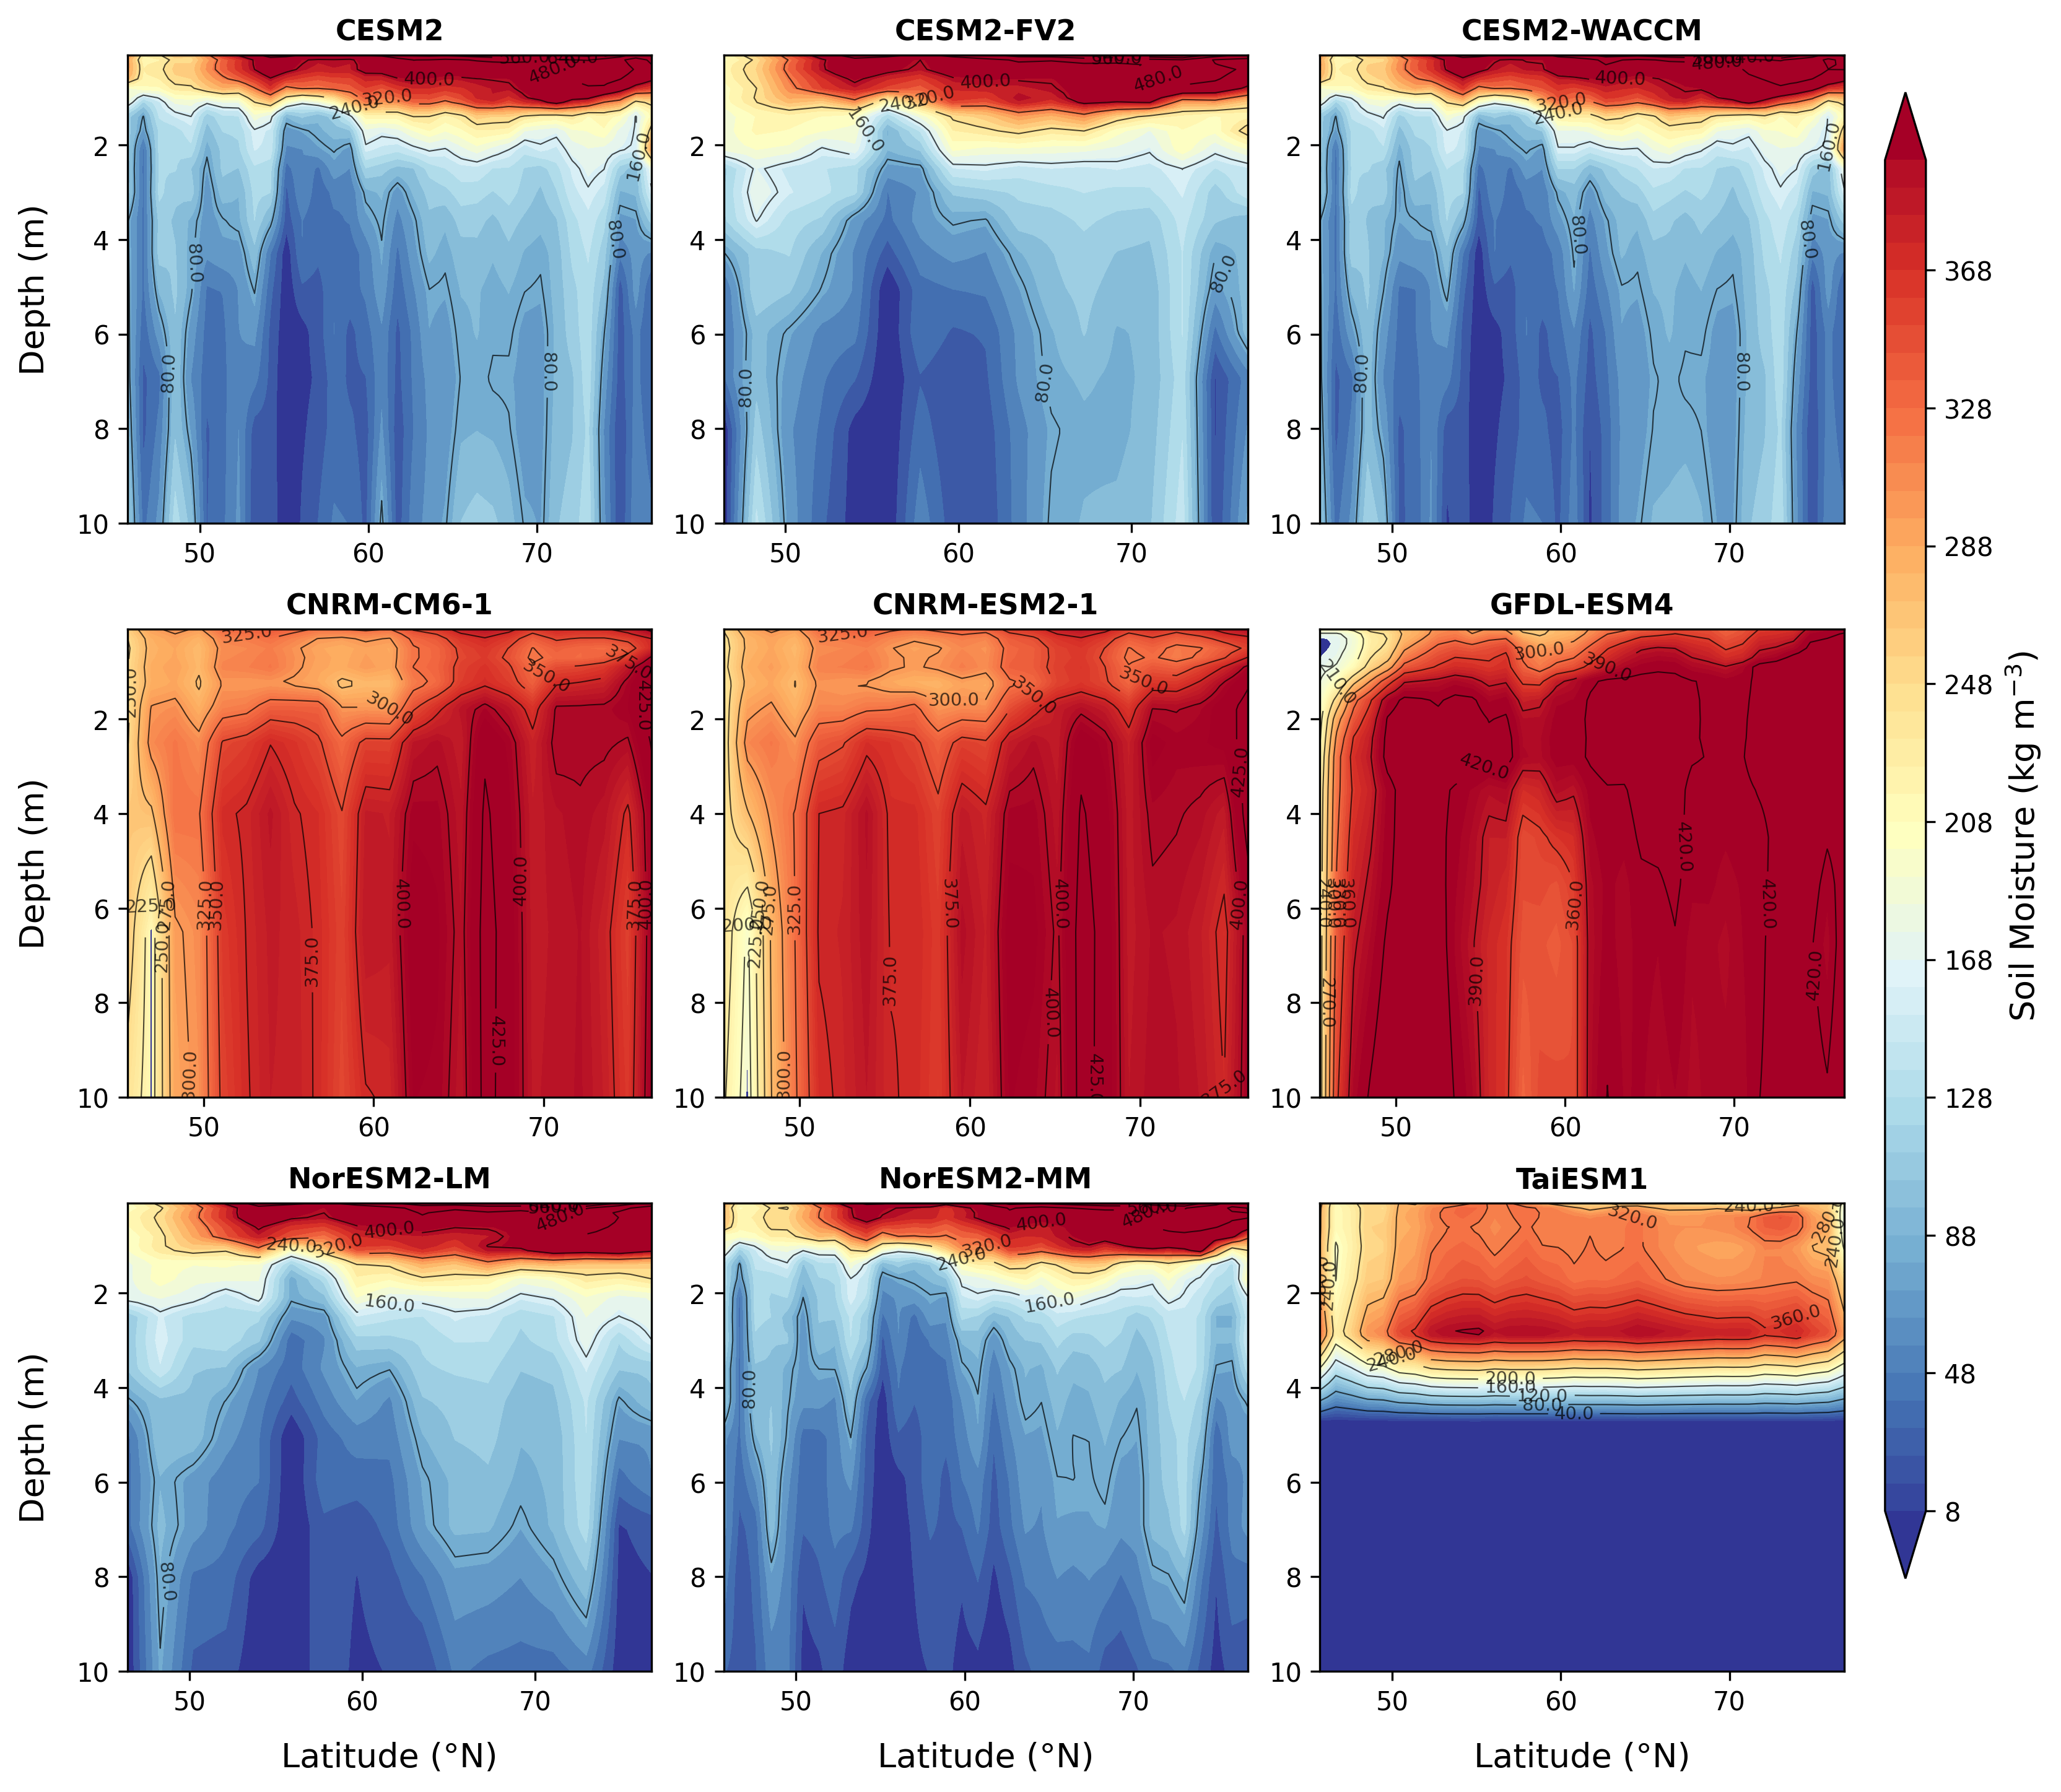

In [ ]:
# Create empty list to store area-weighted mean of total water for each model
depth_profiles_all_models = []

models = ["CESM2",
           "CESM2-FV2", "CESM2-WACCM",
          "CNRM-CM6-1", "CNRM-ESM2-1",
          "GFDL-ESM4", 
          "NorESM2-LM", "NorESM2-MM", 
          "TaiESM1"
          ]

# Data folder paths
data_folder = "..Data/cmip6_mrsfl/"
data_folder2 = "../Data/cmip6_mrsll/"
probability_file = "../Data/probability_lt_threshold_320.nc"

# Read probability threshold data
ds_prob = xr.open_dataset(probability_file)
ds_prob = ds_prob.sel(lon=slice(0, 186))
# Select grid points with probability_lt_threshold > 0
mask = ds_prob['probability_lt_threshold'] > 0
# Create grid for probability data
lon_prob, lat_prob = np.meshgrid(ds_prob.lon.values, ds_prob.lat.values)

# Create 3x3 subplots
fig, axes = plt.subplots(3, 3, figsize=(11, 10), dpi=300)
axes = axes.flatten()

# ==================== Unified colorbar range ====================
vmin_unified = 0
vmax_unified = 410
norm_unified = mcolors.Normalize(vmin=vmin_unified, vmax=vmax_unified)

# Loop through each model
for m, model in enumerate(models):
        
    filepath = glob.glob(data_folder+f"mrsfl_Emon_{model}_*.nc")[0]        
    # Read soil water content data
    ds = xr.open_dataset(filepath)
    ds = ds.sel(lat=slice(45, 77.3), lon=slice(0, 186))

    try:
        # Select time period from 1982 to 2014
        years = np.array([dt.year for dt in ds.time.values])
        year_mask = (years >= 1982) & (years <= 2014)
        ds = ds.isel(time=year_mask)
    except:
        ds = ds.sel(time=slice('1982-01-01', '2014-12-31'))

    filepath2 = glob.glob(data_folder2+f"mrsll_Emon_{model}_*.nc")[0]        
    # Read soil water content data
    ds2 = xr.open_dataset(filepath2)
    ds2 = ds2.sel(lat=slice(45, 77.3), lon=slice(0, 186))

    try:
        # Select time period from 1982 to 2014
        years = np.array([dt.year for dt in ds2.time.values])
        year_mask = (years >= 1982) & (years <= 2014)
        ds2 = ds2.isel(time=year_mask)
    except:
        ds2 = ds2.sel(time=slice('1982-01-01', '2014-12-31'))

    total = (ds['mrsfl'] + ds2['mrsll'])  # shape: (time, depth, lat, lon)

    try:
        depth = ds['depth']
        depth_bnds = ds['depth_bnds']
        thickness = np.empty(len(depth))
        for i in range(len(depth)):
            thickness[i] = depth_bnds.values[i,1]-depth_bnds.values[i,0]         # Calculate thickness
    except:
        try:
            depth = ds['sdepth']
            depth_bnds = ds['sdepth_bounds']
            thickness = np.empty(len(depth))
            for i in range(len(depth)):
                thickness[i] = depth_bnds.values[i,1]-depth_bnds.values[i,0]         # Calculate thickness
        except:
            zhalf_soil = ds['zhalf_soil'].values
            thickness = np.diff(zhalf_soil)         # Calculate thickness
    # Calculate water density (kg/m³)
    density_water_content = total / thickness[None, :, None, None]

    # Create new depth coordinates
    new_depths = np.arange(0.1, 10.1, 0.1)

    # Interpolation
    try:
        density_water_content_interp = density_water_content.interp(
            depth=new_depths, 
            method='linear',
            kwargs={'fill_value': 'extrapolate'}
        )
    except:
        density_water_content_interp = density_water_content.interp(
            sdepth=new_depths, 
            method='linear',
            kwargs={'fill_value': 'extrapolate'}
        )
    # Remove negative values
    density_water_content_interp = density_water_content_interp.clip(min=0)

    # Create grid for soil data
    lon_soil, lat_soil = np.meshgrid(density_water_content_interp.lon.values, density_water_content_interp.lat.values)
    
    # Create grid for probability data
    lon_prob, lat_prob = np.meshgrid(ds_prob.lon.values, ds_prob.lat.values)
    
    # Interpolate mask to soil data grid
    mask_interp = griddata((lon_prob.ravel(), lat_prob.ravel()), 
                            mask.values.ravel(),
                            (lon_soil.ravel(), lat_soil.ravel()), 
                            method='nearest')
    
    mask_interp = mask_interp.reshape(lon_soil.shape).astype(bool)

    # Create mask array with same dimensions as soil data
    mask_da = xr.DataArray(mask_interp, 
                            coords={'lat': density_water_content_interp.lat, 'lon': density_water_content_interp.lon},
                            dims=['lat', 'lon'])

    # Apply mask to filter data
    density_water_masked = density_water_content_interp.where(mask_da, drop=False)

    # Apply land mask
    sftlf = xr.open_dataset(glob.glob(f'../Data/cmip6-fx/sftlf_fx_{model}_*.nc')[0]).sel(lat=slice(45, 77.3), lon=slice(0, 186))['sftlf']
    land_mask_aligned = sftlf.reindex_like(density_water_masked, method='nearest', tolerance=0.01)
    if np.nanmax(land_mask_aligned) == 100:
        land_mask = land_mask_aligned > 50
    else:
        land_mask = land_mask_aligned > 0.5

    density_water_masked = density_water_masked.where(land_mask)
    # Calculate multi-year mean
    mean_yearly_range = density_water_masked.mean(dim='time')
    
    # Calculate latitudinal average (longitude average)
    lat_depth_profile = mean_yearly_range.mean(dim='lon')

    # Create grid for pcolormesh
    lat_2d, depth_2d = np.meshgrid(lat_depth_profile.lat.values, new_depths)
    
    # Plot on current subplot - using unified norm
    ax = axes[m]
    contour = ax.contourf(lat_2d, depth_2d, lat_depth_profile.values, 
                          norm=norm_unified, levels=50, cmap='RdYlBu_r', extend='both')
    
    # Add contour lines
    contour_lines = ax.contour(lat_2d, depth_2d, lat_depth_profile.values, 
                                levels=10, colors='black', linewidths=0.5, alpha=0.7)
    ax.clabel(contour_lines, inline=True, fontsize=7, fmt='%.1f')
    
    # Set subplot title and labels
    ax.set_title(f'{model}', fontsize=11, fontweight='bold')
    if m > 5:
        ax.set_xlabel('Latitude (°N)', fontsize=13, labelpad=10)
    if np.mod(m, 3) == 0:
        ax.set_ylabel('Depth (m)', fontsize=13, labelpad=10)
    
    # Invert depth axis (depth increases downward)
    ax.invert_yaxis()
    
# Adjust subplot spacing
plt.tight_layout()

plt.subplots_adjust(left=0.05, right=0.89, bottom=0.05, top=0.92)

# ==================== Add unified colorbar ====================
cbar_ax = fig.add_axes([0.91, 0.1, 0.02, 0.8])  # [left, bottom, width, height]
cbar = fig.colorbar(contour, cax=cbar_ax, norm=norm_unified, 
                    extend='both', cmap='RdYlBu_r')
cbar.set_label(r'Soil Moisture (kg m$^{-3}$)', fontsize=13)
plt.show()

In [ ]:
fig.savefig("../Figures/FigureS7.png", bbox_inches='tight',dpi=300)